In [1]:
import glob
import os
import sys 
import numpy as np

import torch
import torchvision
from tqdm import tqdm
from torch import nn
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.utils import save_image
#from thop import profile
import torch.nn.functional as F
import os
import gc
import matplotlib.pyplot as plt
import torch.utils.data as data
from PIL import Image
import numpy as np
from torchvision.utils import save_image
import torch
import torch.nn.init as init
#from metrics import jaccard_index, f1_score, LogNLLLoss,classwise_f1
#from utils import chk_mkdir, Logger, MetricList
import cv2
#from functools import partial
#from random import randint
import timeit
#import thop
from torch.cuda.amp import autocast, GradScaler
#from lib.utils import adjust_learning_rate 
import matplotlib.pyplot as plt

In [2]:
#pip install torch

In [3]:
#pip install import-ipynb

len(images_list_all) :   10
__len__
__len__
__len__
__len__
__getitem__
*****************path is : E:\workplace\teases_implementation\dataset\BraTS-GLI-00011-000\BraTS-GLI-00011-000-t1n.nii
*****************path is : E:\workplace\teases_implementation\dataset\BraTS-GLI-00011-000\BraTS-GLI-00011-000-t1c.nii
*****************path is : E:\workplace\teases_implementation\dataset\BraTS-GLI-00011-000\BraTS-GLI-00011-000-t2f.nii
*****************path is : E:\workplace\teases_implementation\dataset\BraTS-GLI-00011-000\BraTS-GLI-00011-000-t2w.nii
*****************path is : E:\workplace\teases_implementation\dataset\BraTS-GLI-00011-000\BraTS-GLI-00011-000-seg.nii
image_ori.shape:    (4, 240, 240, 155)
torch.Size([1, 4, 240, 240, 155])
torch.Size([1, 240, 240, 155])


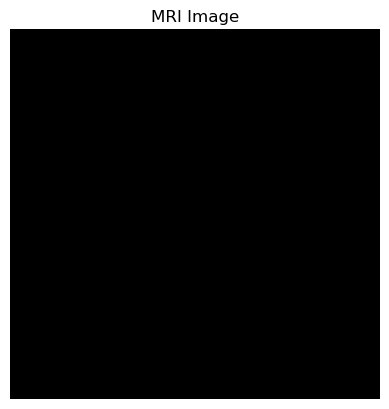

In [4]:
import import_ipynb
import utils_gray_2

In [5]:
#sys.path.insert(0, r'E:\workplace\teases_implementation')
#import utils_gray 

#import myadd

In [6]:
'''import import_ipynb
import myadd
import utils_gray'''

'import import_ipynb\nimport myadd\nimport utils_gray'

In [7]:
from utils_gray_2 import RandomFlip, RandomRotate, RandomContrast,ImageToImage3D_SmallScale
imgchant = 4

In [8]:
path = r"E:\workplace\teases_implementation\dataset"

In [9]:
'''import nibabel as nib

nii = nib.load(os.path.join(self.input_path, 'BraTS-GLI-00012-000-t2f.nii'))

image = nii.get_fdata().astype(np.float32)
image = nii.get_fdata().astype(np.int64)'''


"import nibabel as nib\n\nnii = nib.load(os.path.join(self.input_path, 'BraTS-GLI-00012-000-t2f.nii'))\n\nimage = nii.get_fdata().astype(np.float32)\nimage = nii.get_fdata().astype(np.int64)"

In [10]:
'''t1ce_list = sorted(glob.glob(fr'{path}/*/*t1c.nii'))
t1n_list = sorted(glob.glob(fr'{path}/*/*t1n.nii'))
t2_flair_list = sorted(glob.glob(fr'{path}/*/*t2f.nii'))
t2w_list = sorted(glob.glob(fr'{path}/*/*t2w.nii'))
mask_list = sorted(glob.glob(fr'{path}/*/*seg.nii'))'''

"t1ce_list = sorted(glob.glob(fr'{path}/*/*t1c.nii'))\nt1n_list = sorted(glob.glob(fr'{path}/*/*t1n.nii'))\nt2_flair_list = sorted(glob.glob(fr'{path}/*/*t2f.nii'))\nt2w_list = sorted(glob.glob(fr'{path}/*/*t2w.nii'))\nmask_list = sorted(glob.glob(fr'{path}/*/*seg.nii'))"

In [11]:
'''print(len(t1ce_list))
print(len(t1n_list))
print(len(t2_flair_list))
print(len(t2w_list))
print(len(mask_list))'''

'print(len(t1ce_list))\nprint(len(t1n_list))\nprint(len(t2_flair_list))\nprint(len(t2w_list))\nprint(len(mask_list))'

In [12]:
#print(t1ce_list)

In [13]:
modelname = "gated3d"
imgsize = 224
imgdepth = 160

'''if args.crop is not None:
    crop = (args.crop, args.crop)
else:
    crop = None'''

'if args.crop is not None:\n    crop = (args.crop, args.crop)\nelse:\n    crop = None'

In [14]:
rf_train = RandomFlip(np.random.RandomState(), axis_prob=0.5,axis=0)
rf_val = RandomFlip(np.random.RandomState(), axis_prob=0.5,axis=0)
rr_train = RandomRotate(np.random.RandomState(), angle_spectrum=30)
rr_val = RandomRotate(np.random.RandomState(), angle_spectrum=30)
rc_train = RandomContrast(np.random.RandomState(), alpha=(0.5, 1.5), mean=0.0, execution_probability=0)
rc_val = RandomContrast(np.random.RandomState(), alpha=(0.5, 1.5), mean=0.0, execution_probability=0)

device = torch.device("cuda")

seed = 3407
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed) 
best_val=0
best_loss=99


************************* Num 1 fold *************************
len(images_list_all) :   10
__len__
__len__
__len__
__len__
__getitem__
*****************path is : E:\workplace\teases_implementation\dataset\BraTS-GLI-00008-001\BraTS-GLI-00008-001-t1n.nii
*****************path is : E:\workplace\teases_implementation\dataset\BraTS-GLI-00008-001\BraTS-GLI-00008-001-t1c.nii
*****************path is : E:\workplace\teases_implementation\dataset\BraTS-GLI-00008-001\BraTS-GLI-00008-001-t2f.nii
*****************path is : E:\workplace\teases_implementation\dataset\BraTS-GLI-00008-001\BraTS-GLI-00008-001-t2w.nii
*****************path is : E:\workplace\teases_implementation\dataset\BraTS-GLI-00008-001\BraTS-GLI-00008-001-seg.nii
image_ori.shape:    (4, 240, 240, 155)


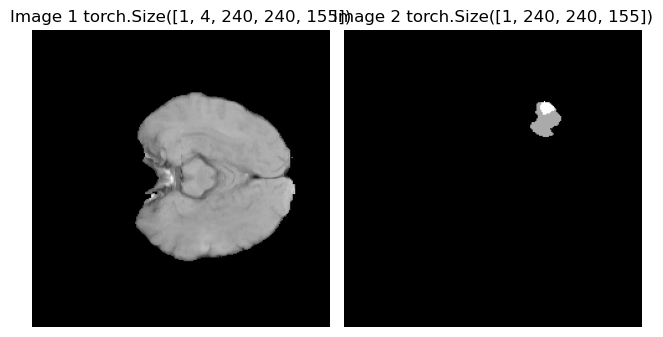

In [17]:
#criterion = LogNLLLoss()

a = 0
tem = 1
kfold=5
batch_size = 1

for i in range(kfold):
    print('*' * 25, 'Num', i + 1, 'fold', '*' * 25)
    train_dataset = ImageToImage3D_SmallScale(Training = True ,shape = (imgdepth,imgsize,imgsize), kfold = kfold, i = i, dataset_path=path,  RandomFlip = rf_train,RandomRotate = rr_train,RandomContrast = rc_train )
    #val_dataset = ImageToImage3D_SmallScale(Training = False ,shape = (imgdepth,imgsize,imgsize), kfold = kfold, i = i, dataset_path=path,  RandomFlip = rf_train,RandomRotate = rr_train,RandomContrast = rc_train)
    dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    my_image ,my_mask, my_name = next(iter(dataloader))
    
    import matplotlib.pyplot as plt
    %matplotlib inline

    # نمایش تصویر اول
    plt.subplot(1, 2, 1)  # 1 سطر، 2 ستون، موقعیت 1
    plt.imshow(my_image[0,0,:,:,50],cmap='gray')
    plt.title(f'Image 1 {my_image.shape}')
    plt.axis('off')
    
    # نمایش تصویر دوم
    plt.subplot(1, 2, 2)  # 1 سطر، 2 ستون، موقعیت 2
    plt.imshow(my_mask[0,:,:,50],cmap='gray')
    plt.title(f'Image 2 {my_mask.shape}')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

    
    break

    
    """
    for batch in dataloader:
        images, masks, filenames = batch
        print("Batch Image Shape:", images.shape)
        print("Batch Mask Shape:", masks.shape)
        print("Filenames:", filenames)
    """

    '''
    if(kfold>1):
        valloader = DataLoader(val_dataset, batch_size=1, shuffle=True)
    else:
        valloader = DataLoader(train_dataset, batch_size=1, shuffle=False)

    train_loss_sum, valid_loss_sum = 0, 0
    train_dice_sum , valid_dice_sum = 0, 0
    
    if modelname == "gated3d":
        model = lib.models.axialnet.gated_3d(img_size=imgsize, img_depth = imgdepth, imgchan=imgchant)

    
     if torch.cuda.device_count() > 1:
        print("Let's use", torch.cuda.device_count(), "GPUs!")
        # dim = 0 [30, xxx] -> [10, ...], [10, ...], [10, ...] on 3 GPUs
        model = nn.DataParallel(model, device_ids=[0, 1]).cuda()
        model.to(device)
        optimizer = torch.optim.AdamW(list(model.parameters()), lr=args.learning_rate,
                                 weight_decay=1e-5, betas=(0.9, 0.999))

    for epoch in range(args.epochs):
        pass
    '''

In [16]:
dataset_path = path
input_path_image = os.path.join(dataset_path, 'images')
input_path_mask = os.path.join(dataset_path, 'masks')
output_path = os.path.join(dataset_path, '')
images_list_all = os.listdir(input_path_image)

#images_list_all

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'E:\\workplace\\teases_implementation\\dataset\\images'